**상위팀 하위팀 공격 및 슈팅 효율 지표 차이 분석**

Question
 - 상위 20% 팀과 하위 20% 팀은 어떤 공격 및 슈팅 효율 특성 차이를 보이는가?
 - 강팀은 어떤 지표에서 구조적으로 우위를 가지는가?

그룹 정의 

#### Good Teams
 - 시즌 승률(W_PCT) 상위 20% 팀
#### Bad Teams
- 시즌 승률(W_PCT) 하위 20% 팀

Metrics
 - PTS
 - FGM
 - FGA
 - eFG%
 - TS%
 - FG3M
 - FTA

Deliverables

 - Good Teams vs Bad Teams 그룹별 평균 비교 바차트
 - 지표별 평균값 테이블
 - 강팀/약팀 공격 프로파일 요약

In [57]:
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

# 1) ranking.csv (승률)
rnk = pd.read_csv("../nba_dataset/ranking.csv")
rnk = rnk[["TEAM_ID", "W_PCT","STANDINGSDATE"]].copy()

# 2) games_details.csv (선수 경기 로그 -> 팀 스탯 만들 재료)
g_detail = pd.read_parquet("../nba_dataset/games_details.parquet")

# 2-1) 필요한 컬럼만 + 숫자형 변환
need_cols = ["TEAM_ID","FGM","FGA","FG3M","FTA","PTS","AST","REB","TO","STL","BLK"]
g = g_detail[need_cols].copy()

num_cols = ["FGM","FGA","FG3M","FTA","PTS","AST","REB","TO","STL","BLK"]
for c in num_cols:
    g[c] = pd.to_numeric(g[c], errors="coerce")

g = g.dropna(subset=["TEAM_ID"])
g["TEAM_ID"] = g["TEAM_ID"].astype(int)

# 2-2) 팀 단위로 집계 (여기서 mean vs sum 선택)
# 보통 '스타일 비교(경기당 평균)' 목적이면 mean 권장
team_base = g.groupby("TEAM_ID", as_index=False)[num_cols].mean()

# 3) 파생 지표(eFG, TS%)
team_base["eFG"] = (team_base["FGM"] + 0.5 * team_base["FG3M"]) / team_base["FGA"]
team_base["TS_PCT"] = team_base["PTS"] / (2 * (team_base["FGA"] + 0.44 * team_base["FTA"]))

# 4) 승률 붙여서 최종 team/t20 만들기
t20 = team_base.merge(rnk, on="TEAM_ID", how="left")

# 5) 최종 확인
t20 = t20[["TEAM_ID","W_PCT","PTS","FGM","FGA","FG3M","FTA","eFG","TS_PCT","AST","REB","TO","STL","BLK"]]
t20.head()


,TEAM_ID,W_PCT,PTS,FGM,FGA,FG3M,FTA,eFG,TS_PCT,AST,REB,TO,STL,BLK
0,1610612737,0.500,9.490596,3.51585,7.769336,0.774989,2.203402,0.502404,0.543013,2.117868,3.942044,1.33527,0.718724,0.445795
1,1610612737,0.500,9.490596,3.51585,7.769336,0.774989,2.203402,0.502404,0.543013,2.117868,3.942044,1.33527,0.718724,0.445795
2,1610612737,0.516,9.490596,3.51585,7.769336,0.774989,2.203402,0.502404,0.543013,2.117868,3.942044,1.33527,0.718724,0.445795
3,1610612737,0.516,9.490596,3.51585,7.769336,0.774989,2.203402,0.502404,0.543013,2.117868,3.942044,1.33527,0.718724,0.445795
4,1610612737,0.500,9.490596,3.51585,7.769336,0.774989,2.203402,0.502404,0.543013,2.117868,3.942044,1.33527,0.718724,0.445795


In [8]:
t20["TEAM_ID"].nunique(), len(t20)


(30, 210342)

In [10]:
#STANDINGSDATE = 해당 순위가 기록된 날짜기준 
rnk2 = pd.read_csv("../nba_dataset/ranking.csv")
rnk2["STANDINGSDATE"] = pd.to_datetime(rnk2["STANDINGSDATE"], errors="coerce")

rnk_latest = (
    rnk2.sort_values("STANDINGSDATE")
        .groupby("TEAM_ID", as_index=False)
        .tail(1)[["TEAM_ID","W_PCT"]]
)

t20 = team_base.merge(rnk_latest, on="TEAM_ID", how="left")
t20.head()

,TEAM_ID,FGM,FGA,FG3M,FTA,PTS,AST,REB,TO,STL,BLK,eFG,TS_PCT,W_PCT
0,1610612737,3.515850,7.769336,0.774989,2.203402,9.490596,2.117868,3.942044,1.335270,0.718724,0.445795,0.502404,0.543013,0.500
1,1610612738,3.491265,7.623064,0.790200,2.192873,9.469240,2.122296,3.910022,1.317100,0.739668,0.443702,0.509817,0.551311,0.688
2,1610612739,3.538782,7.845085,0.788110,2.313728,9.588911,2.053025,4.097520,1.300879,0.679374,0.420831,0.501312,0.540944,0.667
3,1610612740,3.649081,8.036780,0.738338,2.222191,9.729087,2.146277,4.121047,1.303151,0.725723,0.449989,0.499983,0.539633,0.613
4,1610612741,3.604232,8.081023,0.720956,2.218031,9.622656,2.162047,4.245203,1.361653,0.702914,0.481275,0.490620,0.531230,0.419


In [11]:
q20 = t20["W_PCT"].quantile(0.2)
q80 = t20["W_PCT"].quantile(0.8)

t20["tier"] = np.select(
    [t20["W_PCT"] >= q80, t20["W_PCT"] <= q20],
    ["Good (Top 20%)", "Bad (Bottom 20%)"],
    default="Middle"
)

topbot = t20[t20["tier"].isin(["Good (Top 20%)","Bad (Bottom 20%)"])].copy()
topbot["tier"].value_counts()
topbot.head()


,TEAM_ID,FGM,FGA,FG3M,FTA,PTS,AST,REB,TO,STL,BLK,eFG,TS_PCT,W_PCT,tier
1,1610612738,3.491265,7.623064,0.790200,2.192873,9.469240,2.122296,3.910022,1.317100,0.739668,0.443702,0.509817,0.551311,0.688,Good (Top 20%)
2,1610612739,3.538782,7.845085,0.788110,2.313728,9.588911,2.053025,4.097520,1.300879,0.679374,0.420831,0.501312,0.540944,0.667,Good (Top 20%)
6,1610612743,3.758572,8.107552,0.778113,2.519675,10.193465,2.290144,4.196533,1.380740,0.777090,0.486300,0.511576,0.553018,0.633,Good (Top 20%)
8,1610612745,3.674035,8.179162,1.020893,2.469680,10.231202,2.127398,4.264223,1.421444,0.773760,0.462569,0.511603,0.552094,0.290,Bad (Bottom 20%)
12,1610612749,3.616679,7.951117,0.773427,2.219521,9.681109,2.146169,4.080350,1.314831,0.717705,0.451384,0.503501,0.542195,0.710,Good (Top 20%)


In [16]:
metrics = ["PTS","FGM","FGA","FG3M","FTA","eFG","TS_PCT","AST","REB","TO","STL","BLK"]

summary = (
    topbot.groupby("tier")[metrics]
          .mean()
          .T
          .rename(columns={
              "Good (Top 20%)":"Good",
              "Bad (Bottom 20%)":"Bad"
          })
)

summary["diff(Good-Bad)"] = summary["Good"] - summary["Bad"]
summary = summary.sort_values("diff(Good-Bad)", ascending=False)
summary

tier,Bad,Good,diff(Good-Bad)
PTS,9.568800,9.631753,0.062953
AST,2.069262,2.121795,0.052532
FTA,2.273909,2.303301,0.029392
TO,1.295642,1.323049,0.027407
FGM,3.542688,3.564369,0.021681
STL,0.707254,0.727159,0.019905
TS_PCT,0.540000,0.544143,0.004143
eFG,0.500589,0.503457,0.002869
REB,4.043519,4.038371,-0.005148
BLK,0.460161,0.449854,-0.010307


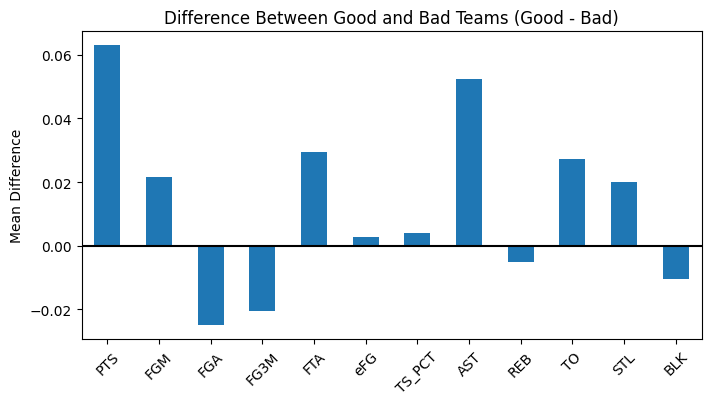

In [14]:
import matplotlib.pyplot as plt
summary["diff(Good-Bad)"].plot(
    kind="bar",
    figsize=(8,4),
    title="Difference Between Good and Bad Teams (Good - Bad)"
)
plt.axhline(0, color="black")
plt.ylabel("Mean Difference")
plt.xticks(rotation=45)
plt.show()



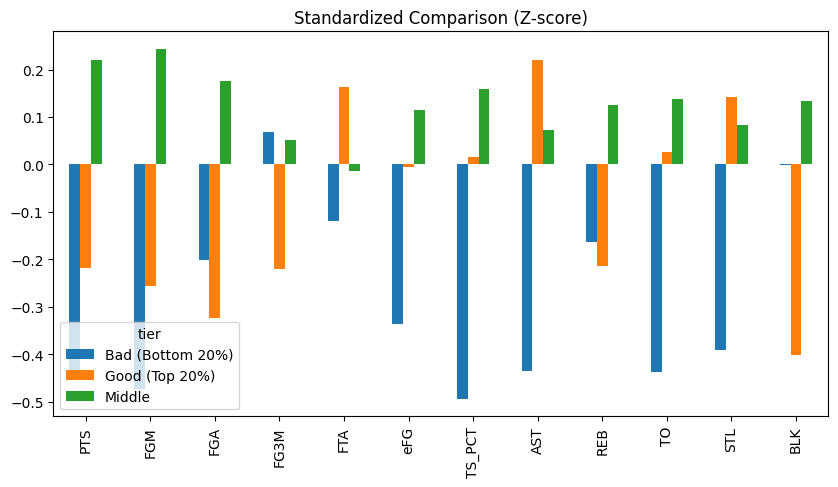

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
z = scaler.fit_transform(t20[metrics])
z_df = pd.DataFrame(z, columns=metrics)
z_df["tier"] = t20["tier"]

z_summary = z_df.groupby("tier")[metrics].mean().T
z_summary.plot(kind="bar", figsize=(10,5))
plt.title("Standardized Comparison (Z-score)")
plt.show()


In [17]:
summary["abs_diff"] = summary["diff(Good-Bad)"].abs()
top5 = summary.sort_values("abs_diff", ascending=False).head(5)
top5

tier,Bad,Good,diff(Good-Bad),abs_diff
PTS,9.568800,9.631753,0.062953,0.062953
AST,2.069262,2.121795,0.052532,0.052532
FTA,2.273909,2.303301,0.029392,0.029392
TO,1.295642,1.323049,0.027407,0.027407
FGA,7.861384,7.836353,-0.025031,0.025031


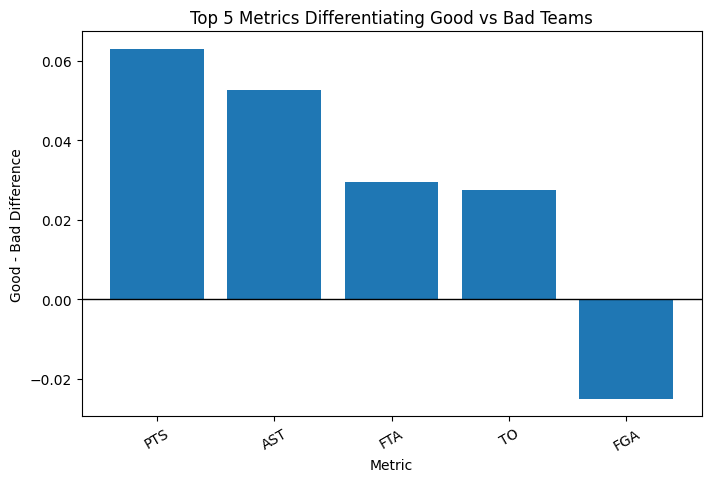

In [18]:
plt.figure(figsize=(8,5))

plt.bar(top5.index, top5["diff(Good-Bad)"])
plt.axhline(0, color="black", linewidth=1)

plt.title("Top 5 Metrics Differentiating Good vs Bad Teams")
plt.xlabel("Metric")
plt.ylabel("Good - Bad Difference")

plt.xticks(rotation=30)
plt.show()

Top 20% 팀과 Bottom 20% 팀을 비교한 결과, 득점(PTS)과 어시스트(AST)가 가장 큰 차이를 보였다. 이는 승률이 높은 팀일수록 개인 의존적인 슛 시도보다 패스 기반의 공격 전개와 효율적인 득점 구조를 갖추고 있음을 의미한다. 반면 하위권 팀은 필드골 시도 수(FGA)는 높으나 승률과는 부정적인 관계를 보여, 공격 효율의 중요성이 확인되었다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler




In [ ]:
#---------------------- 
#회귀계수 파이프라인
#1. 데이터로드
#----------------------

games = pd.read_csv("../nba_dataset/games.csv")
g_detail = pd.read_parquet("../nba_dataset/games_details.parquet")


In [6]:
#---------------------- 
#회귀계수 파이프라인
#2.GameDetails → 팀 단위 집계
#----------------------
import pandas as pd

TEAM_BOX_COLS = ["AST", "REB", "TO", "STL", "BLK"]

# 1) 선수-게임 → 팀-게임 합계 (한 경기 한 팀의 박스스코어)
team_game = (
    g_detail
    .groupby(["GAME_ID", "TEAM_ID"], as_index=False)[TEAM_BOX_COLS]
    .sum()
)

# 2) 팀-게임 → 팀 평균(경기당 평균)
g_team_mean = (
    team_game
    .groupby("TEAM_ID", as_index=False)[TEAM_BOX_COLS]
    .mean()
)

g_team_mean.head()


,TEAM_ID,AST,REB,TO,STL,BLK
0,1610612737,22.546119,41.965692,14.214848,7.651294,4.745782
1,1610612738,22.833333,42.067093,14.170394,7.957934,4.773695
2,1610612739,21.552792,43.016031,13.656716,7.132117,4.417910
3,1610612740,22.282305,42.784051,13.529104,7.534342,4.671711
4,1610612741,22.456559,44.093697,14.143101,7.300965,4.998864


In [ ]:
TEAM_COLS = ["W_PCT", "PTS", "FGM", "FGA", "FG3M", "FTA", "eFG", "TS_PCT"]

team_mean = (
    team 
    .groupby("TEAM_ID", as_index=False)[TEAM_COLS]
    .mean()
)

team_mean.head()


KeyError: 'TEAM_ID'

In [42]:
#---------------------- 
#회귀계수 파이프라인
#3. 파생 지표(eFG, TS%)
#----------------------

team_stats["eFG"] = (team_stats["FGM"] + 0.5 * team_stats["FG3M"]) / team_stats["FGA"]
team_stats["TS_PCT"] = team_stats["PTS"] / (2 * (team_stats["FGA"] + 0.44 * team_stats["FTA"]))


In [43]:
#---------------------- 
#회귀계수 파이프라인
#4.승률(W_PCT) 생성
#----------------------

games["HOME_WIN"] = (games["HOME_TEAM_WINS"] == 1).astype(int)

home = games[["HOME_TEAM_ID","HOME_WIN"]].copy()
home.columns = ["TEAM_ID","WIN"]

away = games[["VISITOR_TEAM_ID","HOME_WIN"]].copy()
away.columns = ["TEAM_ID","WIN"]
away["WIN"] = 1 - away["WIN"]

wins = pd.concat([home, away])

w_pct = (
    wins.groupby("TEAM_ID")["WIN"]
    .mean()
    .reset_index(name="W_PCT")
)


In [44]:
#---------------------- 
#회귀계수 파이프라인
#5.팀 스탯 + 승률 변환
#----------------------
team = team_stats.merge(w_pct, on="TEAM_ID", how="left")
team = team.dropna()
team.head()


,TEAM_ID,FGM,FGA,FG3M,FTA,PTS,AST,REB,TO,STL,BLK,eFG,TS_PCT,W_PCT
0,1610612737,3.515850,7.769336,0.774989,2.203402,9.490596,2.117868,3.942044,1.335270,0.718724,0.445795,0.502404,0.543013,0.468977
1,1610612738,3.491265,7.623064,0.790200,2.192873,9.469240,2.122296,3.910022,1.317100,0.739668,0.443702,0.509817,0.551311,0.560911
2,1610612739,3.538782,7.845085,0.788110,2.313728,9.588911,2.053025,4.097520,1.300879,0.679374,0.420831,0.501312,0.540944,0.511013
3,1610612740,3.649081,8.036780,0.738338,2.222191,9.729087,2.146277,4.121047,1.303151,0.725723,0.449989,0.499983,0.539633,0.461227
4,1610612741,3.604232,8.081023,0.720956,2.218031,9.622656,2.162047,4.245203,1.361653,0.702914,0.481275,0.490620,0.531230,0.501695


In [ ]:
#---------------------- 
#회귀계수 파이프라인
#6.회귀분석용 데이터셋
#----------------------


features = ["PTS","FGM","FGA","FG3M","FTA","eFG","TS_PCT","AST","REB","TO","STL","BLK"]
X = team[features]
y = team["W_PCT"]


In [45]:
#---------------------- 
#회귀계수 파이프라인
#7.표준화 + Train/Test Split
#----------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [46]:
#---------------------- 
#회귀계수 파이프라인
#8.모델 학습
#----------------------

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
#---------------------- 
#회귀계수 파이프라인
#9.성능 평가
#----------------------


y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", round(r2,3))
print("RMSE:", round(rmse,3))


R2: 0.924
RMSE: 0.015


In [48]:
#---------------------- 
#회귀계수 파이프라인
#10.회귀 계수 확인
#----------------------

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df


,Feature,Coefficient
0,PTS,2.781088
5,eFG,0.950460
8,REB,0.061446
10,STL,0.021332
11,BLK,0.003977
7,AST,0.002281
9,TO,-0.032057
3,FG3M,-0.497142
4,FTA,-0.511222
2,FGA,-0.833376


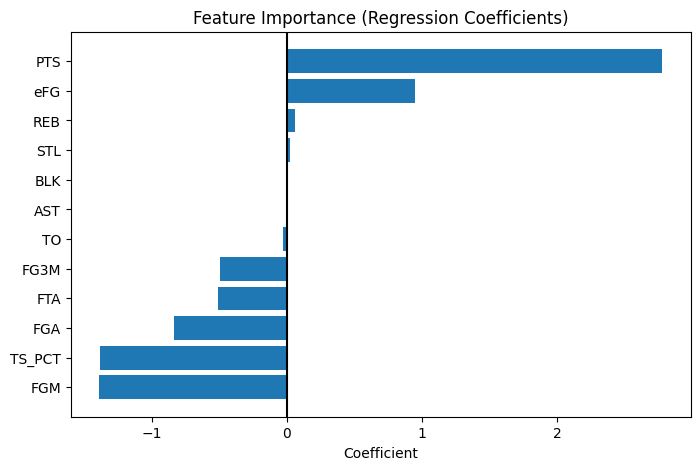

In [32]:
plt.figure(figsize=(8,5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.axvline(0, color="black")
plt.gca().invert_yaxis()
plt.title("Feature Importance (Regression Coefficients)")
plt.xlabel("Coefficient")
plt.show()


팀 승률을 좌우하는 핵심 스타일

 - 많이 득점한다 (PTS)
 - 효율적으로 쏜다 (eFG)
 - 리바운드 경쟁력 있다
 - 수비 이벤트(스틸, 블락) 조금 더 많다

왜 TS%, FGM 같은 게 음수냐?

이건 변수들끼리 강하게 상관되어 있기 때문(다중공선성)
예:

PTS ↑ 하면
→ FGM, FGA, TS%, eFG 전부 같이 움직임

회귀모델은 이렇게 생각함:

"PTS랑 eFG만 있어도 이미 설명 충분한데,
TS%나 FGM이 추가되면 오히려 중복이네?"

그래서 계수를 음수로 눌러서 보정함

 -따라서 이걸 "해석하면 안 되는 음수"라고 보면 안 됨

In [49]:
t20[features + ["W_PCT"]].corr()["W_PCT"].sort_values(ascending=False)


W_PCT     1.000000
TS_PCT    0.213075
AST       0.208407
TO        0.205746
STL       0.176910
eFG       0.171611
FGM       0.156333
PTS       0.121493
FTA       0.045263
FGA       0.001880
REB      -0.029646
FG3M     -0.090724
BLK      -0.217335
Name: W_PCT, dtype: float64

<Axes: >

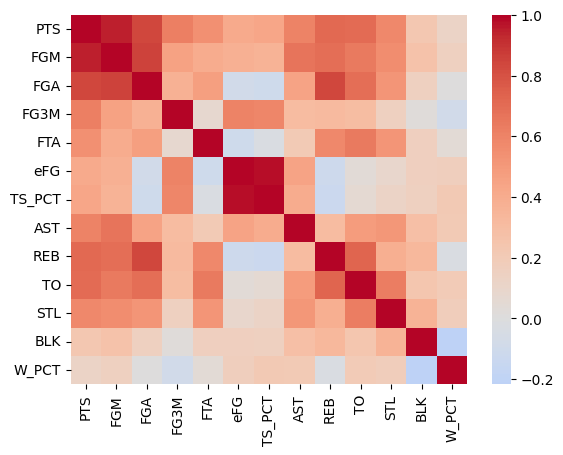

In [50]:
import seaborn as sns
sns.heatmap(t20[features+["W_PCT"]].corr(), cmap="coolwarm", center=0)


슈팅 효율(TS%, eFG)
✔ 패스/공유(어시스트)
✔ 볼 압박(스틸)

이 세 묶음이 승률과 가장 밀접

 **의외 포인트**
## TO(턴오버)가 양수

보통은 TO ↑ → 나쁠 것 같지만
지금 데이터에서는 속공/템포 빠른 팀이:

패스도 많고(AST↑)
공격 시도도 많고(FGA↑)
그 과정에서 턴오버도 같이 많음

즉,"공격 볼륨 큰 팀" 효과
 ->나쁜 턴오버라기보다 공격 기회가 많다는 신호

## BLK가 음수 (-0.217)

가능한 해석:

블락 많은 팀 = 수비가 자주 무너져서 헬프 수비 상황이 많다

또는, 강팀은 포지셔닝 수비로 막고 블락까지 갈 일이 적음

즉,블락은 "좋은 수비"라기보다
"위기 상황에서 나오는 이벤트"일 수 있음

In [51]:
#----------------------
#lasso 회귀 모델
#----------------------

from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

In [53]:
features = ["PTS","FGM","FGA","FG3M","FTA","eFG","TS_PCT",
            "AST","REB","TO","STL","BLK"]

X = t20[features]
y = t20["W_PCT"]

# ---------------------------
# 2. Train / Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# 3. Pipeline (표준화 + Lasso)
# ---------------------------
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.001))
])

# ---------------------------
# 4. 학습
# ---------------------------
lasso_pipe.fit(X_train, y_train)

# ---------------------------
# 5. 예측 및 성능
# ---------------------------
y_pred = lasso_pipe.predict(X_test)

print("R2:", round(r2_score(y_test, y_pred),3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)),3))

# ---------------------------
# 6. 계수 확인
# ---------------------------
coef = lasso_pipe.named_steps["lasso"].coef_

lasso_coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coef
}).sort_values(by="Coefficient", ascending=False)

lasso_coef_df

R2: -3.216
RMSE: 0.212


/Users/jisoyun/Desktop/sparta_python/workspace/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.389e-04, tolerance: 3.949e-05
  model = cd_fast.enet_coordinate_descent(


,Feature,Coefficient
6,TS_PCT,0.136487
8,REB,0.096466
10,STL,0.078061
9,TO,0.042822
0,PTS,-0.000000
1,FGM,-0.011485
3,FG3M,-0.011658
7,AST,-0.026000
4,FTA,-0.040940
2,FGA,-0.057979


In [56]:
rnk11 = pd.read_csv("../nba_dataset/ranking.csv")
rnk11.columns

Index(['TEAM_ID', 'LEAGUE_ID', 'SEASON_ID', 'STANDINGSDATE', 'CONFERENCE',
       'TEAM', 'G', 'W', 'L', 'W_PCT', 'HOME_RECORD', 'ROAD_RECORD',
       'RETURNTOPLAY'],
      dtype='object')